# AG-HYPOPT · Trial 08

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Seven trials. Best: **trial_06** `cvm_fwhm` **0.0764** (sw 0.2074), then trial_05 `cvm_fwhm` **0.0777**
(sw 0.2345); the KDE control is **0.080328**. Trial_07 ran KDE at sw 0.2279 -> **0.0830**, i.e. no better
than its own reference, which rules out the idea that the win is just the low-`sigma_weight` region: the
loss FORM matters. The two `cvm_fwhm` points suggest the objective falls as sw drops across 0.2345 ->
0.2074 (0.0777 -> 0.0764), but the sw dependence is only mapped in that narrow band. Other families:
`w1_2d` 0.0895, `w1_fwhm` 0.0908, `energy_2d` 0.0996, `mmd_2d` 0.1833. No divergences anywhere.
Phase `trials` (7/5), EI-guided.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_08'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (7/5 trials)
ID |     ei | params
 1 | 2.5385 | {"loss_family": "energy_2d", "sigma_weight": 0.2161460162114953}
 2 | 3.6295 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.23196158213865337}
 3 | 2.5224 | {"loss_family": "mmd_2d", "sigma_weight": 0.22043200653016967}
 4 | 1.1980 | {"loss_family": "mmd_2d", "sigma_weight": 0.25714524855112975}
 5 | 1.2571 | {"loss_family": "w1_2d", "sigma_weight": 0.813827670155021}
 6 | 0.3782 | {"loss_family": "mmd_2d", "sigma_weight": 0.5909028517654116}
 7 | 2.5501 | {"loss_family": "w1_fwhm", "sigma_weight": 0.21235935278425605}
 8 | 2.5501 | {"loss_family": "w1_2d", "sigma_weight": 0.212329705584047}
 9 |      - | {"loss_family": "cvm_fwhm", "sigma_weight": 0.1815539373627295}
10 |      - | {"loss_family": "kde", "sigma_weight": 0.3946685812986028}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The campaign has a clear leader (`cvm_fwhm`, 0.0764/0.0777) and trial_07 confirmed it is a loss-form
effect, not a low-sw artifact. So the productive direction is to **map the winner's own `sigma_weight`
trend**. The two existing `cvm_fwhm` points are sw 0.2074 (0.0764) and 0.2345 (0.0777) - the objective
improved as sw fell - so probing further down is the natural exploitation move.

Scanning the table: the top-EI candidate 2 (`cvm_fwhm`, sw 0.2320, ei 3.6295) sits right on top of
trial_05's sw and would mostly re-confirm ~0.0777; candidates 1/3/4/5/6/7/8 are the weaker families at
low sw (useful later, but none has shown a single result near the leader). Candidate 9 is `cvm_fwhm` at
**sw 0.1816** - just below the current best's sw, extending the winning family's trend into new terrain,
and is the more informative exploitation step than a near-duplicate of trial_05.

I choose candidate 9.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 9             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'cvm_fwhm', 'sigma_weight': 0.1815539373627295}
Running  1nW Trans05 ... 

μ 9.39 -> 5.44 | γ 8.5 -> 4.21 | NLL 158.45


Running  1nW Trans20 ... 

μ 17.32 -> 22.86 | γ 8.5 -> 5.74 | NLL 1.03


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 61.74 | γ 14.1 -> 14.00 | NLL 0.19


Running 3nW Trans100 ... 

μ 175.71 -> 99.11 | γ 14.1 -> 13.34 | NLL 0.45



Total: 7.7 min


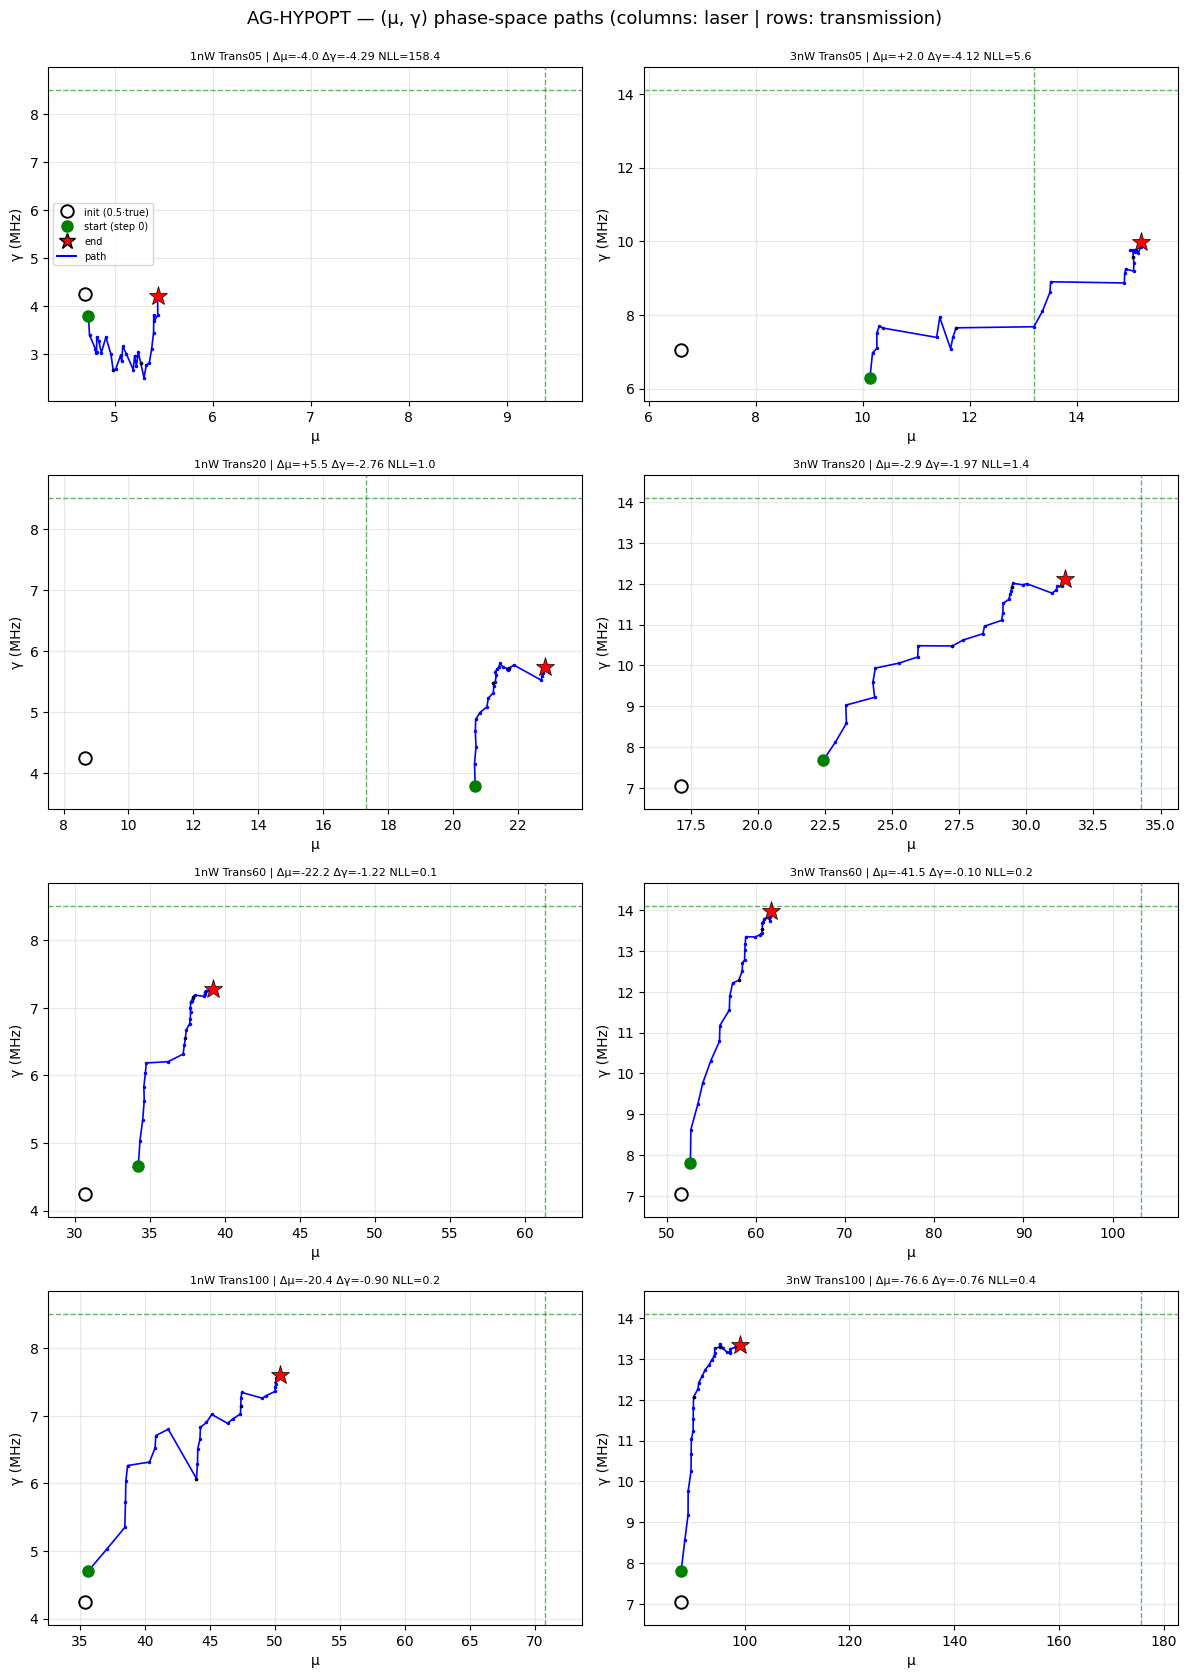

trial finished in 7.7 min
objective = 0.0791 ± 0.0199
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.44   -42.1 |     8.50    4.21   -50.4
1nW Trans20       17.32   22.86   +32.0 |     8.50    5.74   -32.5
1nW Trans60       61.37   39.21   -36.1 |     8.50    7.28   -14.4
1nW Trans100       70.82   50.39   -28.8 |     8.50    7.60   -10.6
3nW Trans05       13.20   15.21   +15.2 |    14.10    9.98   -29.2
3nW Trans20       34.28   31.43    -8.3 |    14.10   12.13   -14.0
3nW Trans60      103.20   61.74   -40.2 |    14.10   14.00    -0.7
3nW Trans100      175.71   99.11   -43.6 |    14.10   13.34    -5.4

weighted objective (T-graded, cap=1.0) = 0.0791 | diverged cells: 0
μ: RMSE 32.699 (rel 33.1%, bias -19.990) | γ: RMSE 2.495 (rel 25.0%, bias -2.016)


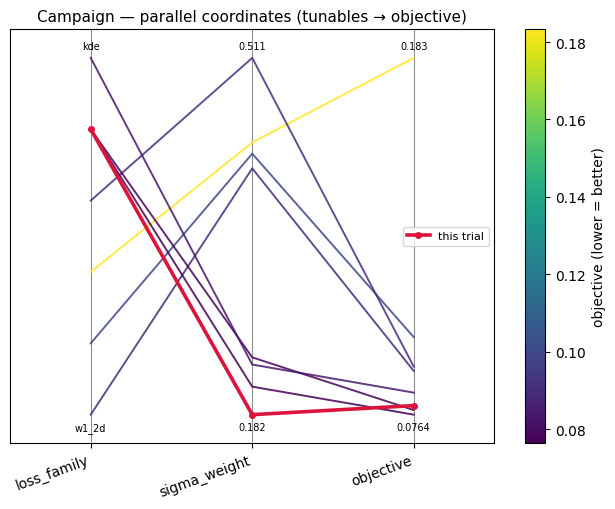

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'cvm_fwhm', sigma_weight: 0.1816}` (candidate 9). Trial
time 7.7 min, objective **0.0791 +/- 0.0199**, **0 diverged cells**. Still below the KDE control
(0.0803), but *worse* than the two existing `cvm_fwhm` points: trial_06 (sw 0.2074 -> 0.0764) and
trial_05 (sw 0.2345 -> 0.0777).

**What this trial shows.** It extends the `cvm_fwhm` sw trend below 0.2074 and the trend is **not
monotone**: 0.1816 -> 0.0791, 0.2074 -> 0.0764, 0.2345 -> 0.0777. So the family has a shallow minimum
around sw ~0.20-0.21, and pushing sw lower (this trial) or higher (trial_05) both give back ~0.0027.

**Per-cell behaviour.** Again the low-count cells barely move (1nW Trans05 identical at mu 5.44 /
gamma 4.21, as in trials 06 and 08 both at the low end), while the mid/high-T cells carry the change:

- 1nW Trans05: mu -42.1 %, gamma 8.5 -> 4.21 (-50.4 %).
- 1nW Trans20: mu +32.0 %, gamma -32.5 %.
- 1nW Trans60 / Trans100: mu -36.1 % / -28.8 %, gamma -14.4 % / -10.6 % (Trans100 gamma worse than
  trial_06's -9.1 %).
- 3nW Trans05 / Trans20: mu +15.2 % / -8.3 %, gamma -29.2 % / -14.0 %.
- 3nW Trans60 / Trans100: mu -40.2 % / -43.6 %, gamma -0.7 % / -5.4 %.

**Aggregates.** mu: RMSE 32.70 (rel 33.1 %), bias -19.99; gamma: RMSE 2.49 (rel 25.0 %), bias -2.02 -
gamma again between the two earlier `cvm_fwhm` values (2.40-2.47), so the differences among these three
trials are small but consistent.

**Summary:** `cvm_fwhm` at sw 0.1816 gives objective 0.0791, still under the control but worse than the
same family at sw 0.2074 (0.0764), so the sw axis has a shallow minimum near 0.20-0.21.
**Key insight:** `cvm_fwhm`'s `sigma_weight` response is non-monotone with a shallow minimum around
sw ~0.20-0.21; trial_06's setting is near the family optimum.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'cvm_fwhm at sigma_weight 0.1816 gives objective 0.0791, still under the KDE control but worse than the same family at sw 0.2074 (0.0764), so the sw axis has a shallow minimum near 0.20-0.21.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'cvm_fwhm sigma_weight response is non-monotone with a shallow minimum around sw ~0.20-0.21, so trial_06 setting is near the family optimum.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_08 | current best: trial_06


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_09.ipynb. Open it and follow its cells from the top.
